# (08) New Implementation: working?

host: ```yoru```, device: ```cuda:0```

**motivation:** <br>

Let's try t_train = 32 and t_tbptt = 16.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## 64 = 16 (x 4)  . . .  beta = 64.0

- t_train = 64
- t_tbptt = 16
- beta = 64.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 64
cfg_mod['t_tbptt'] = 16
cfg_mod['beta_outer'] = 64.0

# cfg_tr['batch_size'] = 200
# cfg_tr['epochs'] = 10

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

154500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-64[§16]_b-64_k-[512]_u-10,du-10
b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10], device='cuda:0',
       dtype=torch.int32)

In [7]:
tr.train()

epoch # 300, avg loss: 224.158: 100%|█████| 300/300 [18:20:44<00:00, 220.15s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([122, 130, 138, 146, 154, 162, 170, 177, 185, 192, 198, 205, 211, 216,
        221, 226, 231, 235, 238, 242, 245, 248, 250, 253, 255, 257, 258, 260,
        261, 262, 263, 264, 265, 266, 267, 267, 268, 268, 269, 269, 269, 270,
        270, 270, 270, 271, 271, 271, 271, 271, 271, 271, 271, 271, 271, 271,
        270, 270, 270, 270, 270, 270, 270, 270], device='cuda:0',
       dtype=torch.int32)

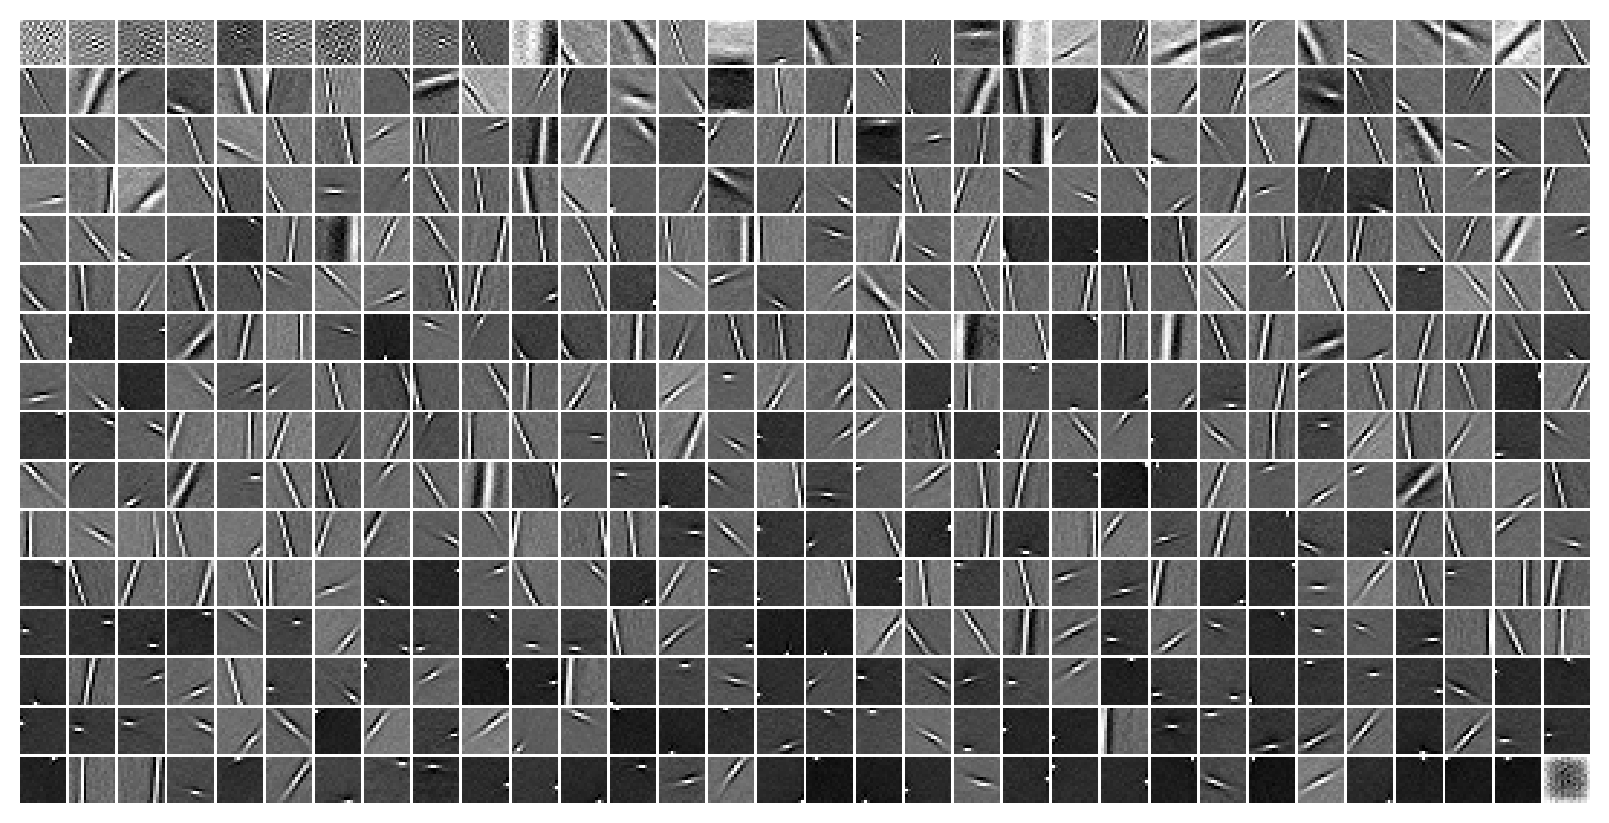

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [10]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:39<00:00, 509.23it/s]


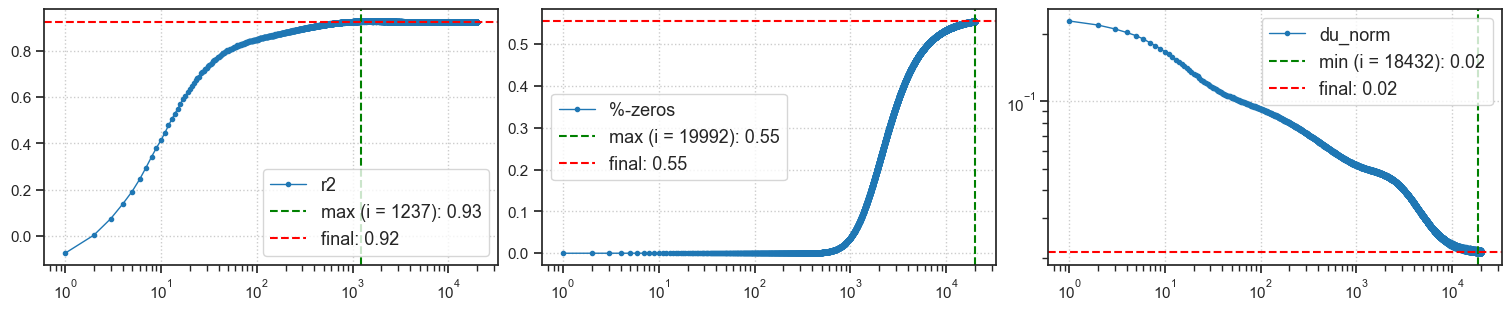

In [11]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

## 32 = 16 § 2 . . . beta = 16.0

- t_train = 32
- t_tbptt = 16
- beta = 16.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 32
cfg_mod['t_tbptt'] = 16
cfg_mod['beta_outer'] = 16.0

# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 100

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

51500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-32[§16]_b-16_k-[512]_u-10,du-10
b200-ep100-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [7]:
tr.train()

epoch # 100, avg loss: 184.028: 100%|███████| 100/100 [2:41:26<00:00, 96.87s/it]


In [10]:
print(tr.model.layer.n_exp)

tensor([ 41,  61,  89, 123, 155, 180, 195, 205, 209, 211, 213, 213, 213, 213,
        213, 212, 212, 212, 212, 212, 212, 212, 212, 212, 212, 213, 212, 212,
        213, 212, 213, 213], device='cuda:0', dtype=torch.int32)

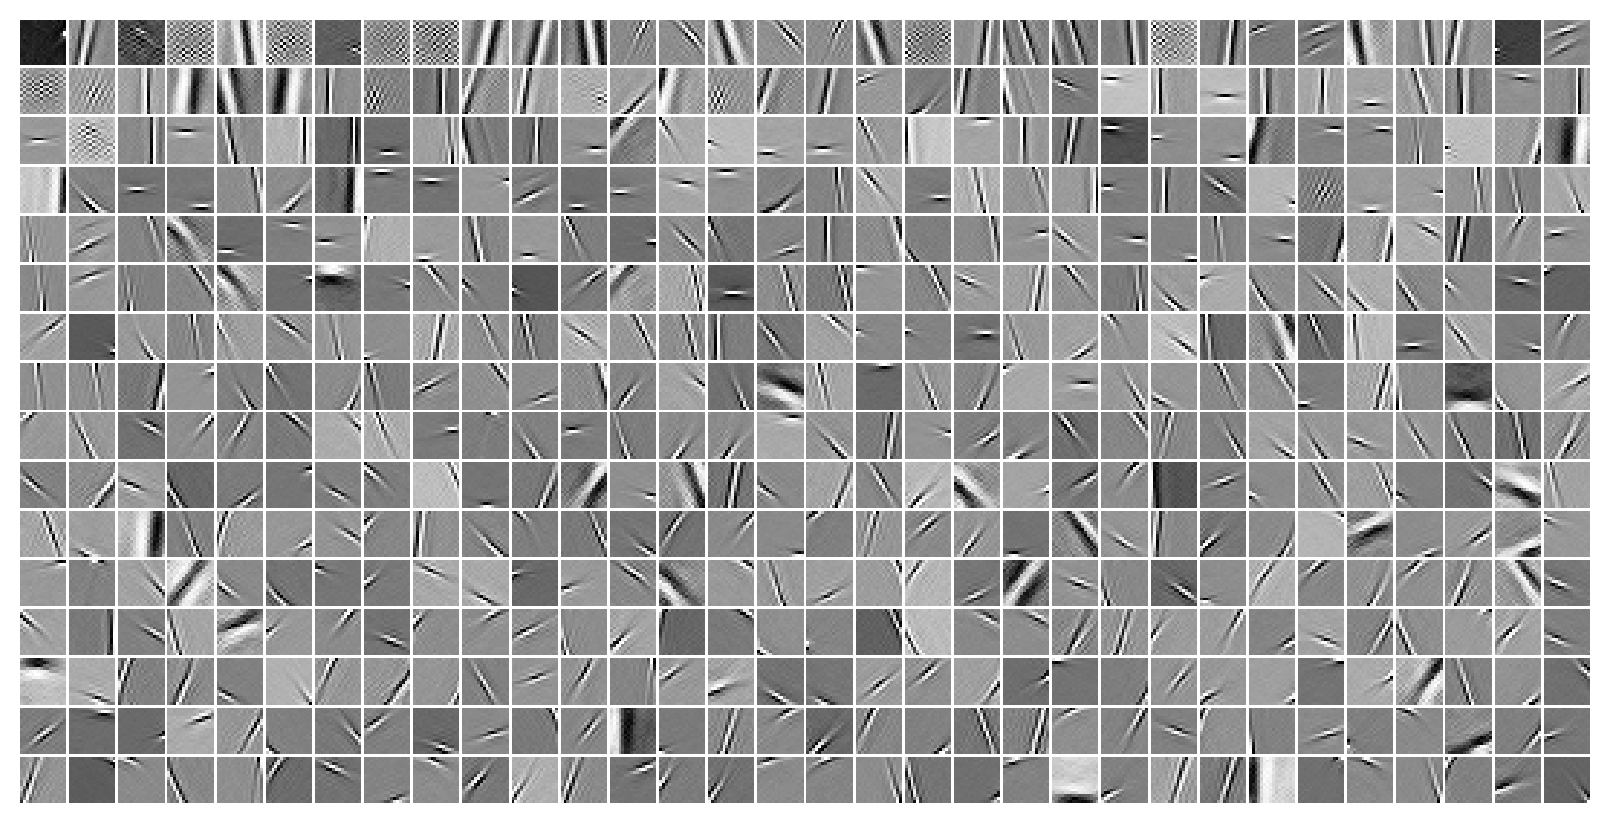

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [12]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:39<00:00, 506.49it/s]


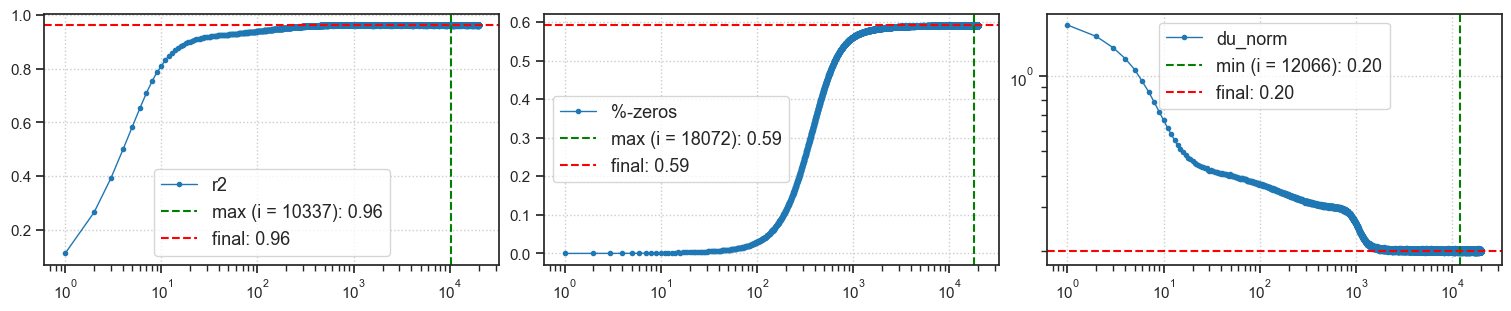

In [13]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()